In [1]:
import glob
import copy
import numpy as np

# CityLearn Imports
from citylearn.citylearn import CityLearnEnv
from citylearn.agents.rbc import OptimizedRBC
from citylearn.agents.base import Agent

# Train (no need to, so definition of RBC here)

In [2]:
# ------------------------------------------------------------------
# 0. Global Parameters
# ------------------------------------------------------------------
num_houses = 1
base_schema = "citylearn_challenge_2023_phase_3_1"

In [3]:
temp_env = CityLearnEnv(schema=base_schema)
schema_dict = copy.deepcopy(temp_env.schema)
building_names = list(schema_dict["buildings"].keys())

if num_houses < len(building_names):
    target_buildings = building_names[:num_houses]
    schema_dict["buildings"] = {b: schema_dict["buildings"][b] for b in target_buildings}

INFO:root:Go here /home/ntpt/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


In [4]:
class CustomCentralizedRBCAgent(Agent):
    def __init__(self, env, **kwargs):
        # 1. Initialize the parent class FIRST to set up __env and other base attributes
        super().__init__(env, **kwargs)
        # env.action_space is a List of Box spaces; target the centralized Box
        self.action_space = env.action_space[0]

        # env.observation_names is a List[List[str]]; extract the flat list of strings
        self.obs_names = env.observation_names[0]

        self.building_names = [b.name for b in env.buildings]

    def predict(self, observations, deterministic=False):
        """
        Dynamically parses the flat centralized array and applies RBC heuristics.
        """
        # observations is a List[List[float]]. Extract the centralized agent's array
        flat_obs = observations[0]

        # 1. Unpack the array and map it to a dictionary
        state = dict(zip(self.obs_names, flat_obs))

        # Extract global variables (These don't have building prefixes)
        hour = state.get("hour", 12)

        centralized_action = []

        # 2. Iterate through each building to apply local heuristics
        for b_index, b_name in enumerate(self.building_names):
            # Initialize neutral actions: [DHW, Battery, Cooling]
            # Ensure the length matches the number of active actions per building
            building_action = [0.0, 0.0, 0.0]

            # Dynamically extract this specific building's local telemetry
            indoor_temp = state.get("indoor_dry_bulb_temperature")
            setpoint = state.get("indoor_dry_bulb_temperature_cooling_set_point")

            # --- Battery Heuristics ---
            if 17 <= hour <= 21:
                building_action[1] = -0.5  # Discharge
            elif 2 <= hour <= 6:
                building_action[1] = 0.5  # Charge

            # --- HVAC Heuristics ---
            # if indoor_temp is not None and setpoint is not None:
            if indoor_temp > setpoint:
                # Actuate cooling if temperature exceeds upper deadband
                building_action[2] = min(5 * (indoor_temp - setpoint), 1.0)

            # print(building_action[2], indoor_temp, setpoint)

            # Append to the master centralized array
            centralized_action.extend(building_action)

        # 3. Clip and return the final action array
        action_array = np.array(centralized_action, dtype=np.float32)
        clipped_action = np.clip(action_array, self.action_space.low, self.action_space.high)

        # CityLearn expects List[List[float]]
        return [clipped_action.tolist()]

# Evaluate (get KPIs)

In [5]:
# initialize
env = CityLearnEnv(schema_dict, central_agent=True)
model = CustomCentralizedRBCAgent(env)

# step through environment and apply agent actions
observations, _ = env.reset()

action_history = []
dynamic_indoor_temp = []
dynamic_setpoint = []

In [6]:
while not env.terminated:
    # 1. Extract the current state exactly as the agent sees it
    flat_obs = observations[0]
    state = dict(zip(model.obs_names, flat_obs))

    # 2. Log the dynamic telemetry
    dynamic_indoor_temp.append(state.get("indoor_dry_bulb_temperature"))
    dynamic_setpoint.append(state.get("indoor_dry_bulb_temperature_cooling_set_point"))

    # 3. Predict and log the action
    actions = model.predict(observations)
    action_history.append(actions[0])

    # 4. Step the environment
    observations, reward, info, terminated, truncated = env.step(actions)

# Convert lists to numpy arrays for plotting
action_history = np.array(action_history)
dynamic_indoor_temp = np.array(dynamic_indoor_temp)
dynamic_setpoint = np.array(dynamic_setpoint)

In [7]:
# test
kpis = model.env.evaluate()
kpis = kpis.pivot(index="cost_function", columns="name", values="value").round(3)
kpis = kpis.dropna(how="all")

from pathlib import Path

kpi_csv_save_path = Path.cwd() / "kpi" / "single_house_rbc.csv"
kpis.to_csv(kpi_csv_save_path)

display(kpis)

name,Building_1,District
cost_function,,
all_time_peak_average,NaN,0.962
annual_normalized_unserved_energy_total,0.016,0.016
carbon_emissions_total,0.605,0.605
cost_total,0.551,0.551
daily_one_minus_load_factor_average,NaN,1.236
daily_peak_average,NaN,0.889
discomfort_cold_delta_average,0.223,0.223
discomfort_cold_delta_maximum,7.080,7.080
discomfort_cold_delta_minimum,0.000,0.000


# Investigate agent behavior

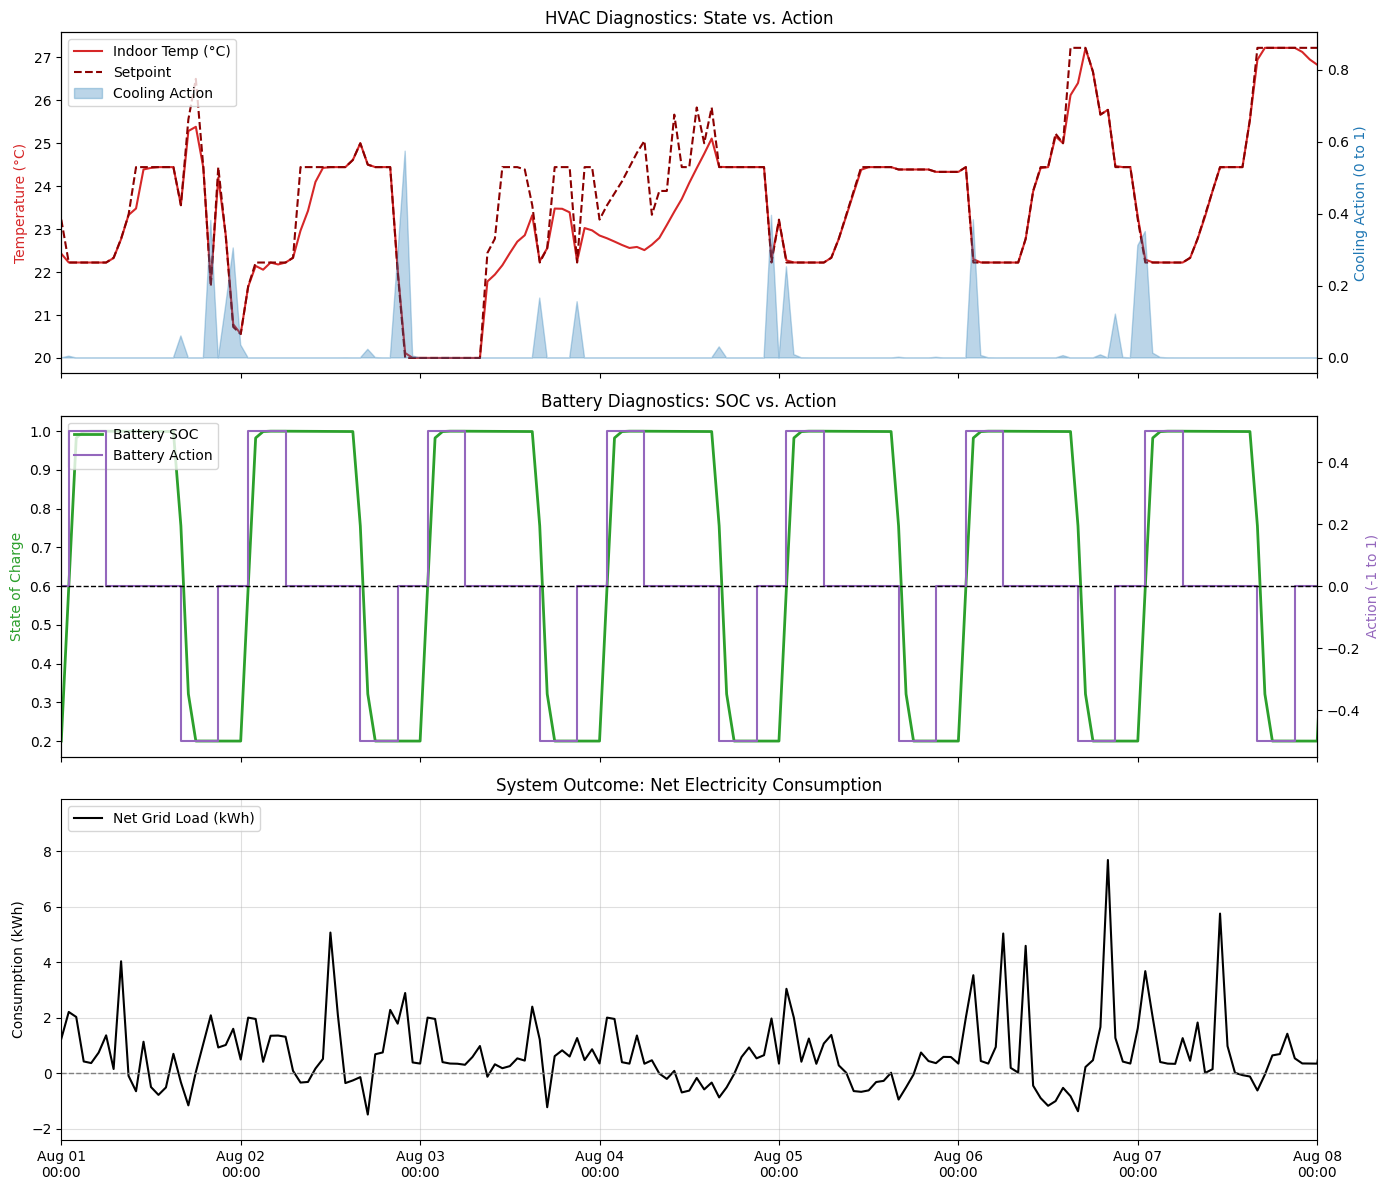

In [83]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# 1. Define time and telemetry length
T = len(action_history)

# 2. Generate hourly timestamps based on the length of the simulation
start_date = pd.Timestamp("2023-08-01 00:00:00")
timestamps = pd.date_range(start=start_date, periods=T, freq="h")

# 3. Slice telemetry to match length T
building = env.buildings[0]
# Use the dynamically logged telemetry instead of the baseline building object
indoor_temp = dynamic_indoor_temp
setpoint = dynamic_setpoint
soc = building.electrical_storage.soc[:T]
net_load = building.net_electricity_consumption[:T]

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Plot 1: HVAC ---
color_temp = "tab:red"
axs[0].plot(timestamps, indoor_temp, label="Indoor Temp (°C)", color=color_temp)
axs[0].plot(timestamps, setpoint, label="Setpoint", color="darkred", linestyle="--")
axs[0].set_ylabel("Temperature (°C)", color=color_temp)

ax0_twin = axs[0].twinx()
color_act = "tab:blue"
ax0_twin.fill_between(
    timestamps, 0, action_history[:, 2], alpha=0.3, color=color_act, label="Cooling Action"
)
ax0_twin.set_ylabel("Cooling Action (0 to 1)", color=color_act)
axs[0].set_title("HVAC Diagnostics: State vs. Action")

# Combine legends
l1, lab1 = axs[0].get_legend_handles_labels()
l2, lab2 = ax0_twin.get_legend_handles_labels()
axs[0].legend(l1 + l2, lab1 + lab2, loc="upper left")

# --- Plot 2: Battery ---
color_soc = "tab:green"
axs[1].plot(timestamps, soc, label="Battery SOC", color=color_soc, linewidth=2)
axs[1].set_ylabel("State of Charge", color=color_soc)

ax1_twin = axs[1].twinx()
color_b_act = "tab:purple"
ax1_twin.step(
    timestamps, action_history[:, 1], where="post", label="Battery Action", color=color_b_act
)
ax1_twin.axhline(0, color="black", linewidth=1, linestyle="--")
ax1_twin.set_ylabel("Action (-1 to 1)", color=color_b_act)
axs[1].set_title("Battery Diagnostics: SOC vs. Action")

l1, lab1 = axs[1].get_legend_handles_labels()
l2, lab2 = ax1_twin.get_legend_handles_labels()
axs[1].legend(l1 + l2, lab1 + lab2, loc="upper left")

# --- Plot 3: Net Grid Load ---
axs[2].plot(timestamps, net_load, label="Net Grid Load (kWh)", color="black")
axs[2].axhline(0, color="gray", linewidth=1, linestyle="--")
axs[2].set_ylabel("Consumption (kWh)")
axs[2].set_title("System Outcome: Net Electricity Consumption")
axs[2].legend(loc="upper left")
axs[2].grid(True, alpha=0.4)

# 4. Format the X-Axis for Wall-Clock Time
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
plt.xticks(rotation=0)

plt.tight_layout()

# View the first 7 days
plt.xlim(timestamps[0], timestamps[168])
plt.show()

# Environment details (for debug - don't care)

In [77]:
env.action_names

[['dhw_storage', 'electrical_storage', 'cooling_device']]

In [78]:
env.action_space

[Box([-1. -1.  0.], 1.0, (3,), float32)]

In [79]:
env.observation_space

[Box([ 1.0000000e+00  1.0000000e+00  1.8160000e+01  1.7735878e+01
   1.8267269e+01  1.7025522e+01  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  2.7006584e-01  7.6293945e-06
   3.0811283e-01  0.0000000e+00  0.0000000e+00  0.0000000e+00
  -4.6562166e+00  3.0250000e-02  3.0250000e-02  3.0250000e-02
   3.0250000e-02  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  2.0000000e+01], [7.0000000e+00 2.4000000e+01 3.8110001e+01 3.8912338e+01 3.8959305e+01
  3.9400982e+01 5.0084000e+02 5.6977252e+02 5.7735968e+02 6.3289221e+02
  9.1862000e+02 1.0693932e+03 1.1619512e+03 1.1784778e+03 5.6347221e-01
  4.7222275e+01 7.4589686e+00 1.7110062e+00 1.0000000e+00 1.0000000e+00
  1.9749760e+01 6.6050000e-02 6.6050000e-02 6.6050000e-02 6.6050000e-02
  2.1705509e+01 9.0590181e+00 3.0000000e+00 1.0000000e+00 2.7222221e+01], (30,), float32)]

In [80]:
env.observation_names

[['day_type',
  'hour',
  'outdoor_dry_bulb_temperature',
  'outdoor_dry_bulb_temperature_predicted_1',
  'outdoor_dry_bulb_temperature_predicted_2',
  'outdoor_dry_bulb_temperature_predicted_3',
  'diffuse_solar_irradiance',
  'diffuse_solar_irradiance_predicted_1',
  'diffuse_solar_irradiance_predicted_2',
  'diffuse_solar_irradiance_predicted_3',
  'direct_solar_irradiance',
  'direct_solar_irradiance_predicted_1',
  'direct_solar_irradiance_predicted_2',
  'direct_solar_irradiance_predicted_3',
  'carbon_intensity',
  'indoor_dry_bulb_temperature',
  'non_shiftable_load',
  'solar_generation',
  'dhw_storage_soc',
  'electrical_storage_soc',
  'net_electricity_consumption',
  'electricity_pricing',
  'electricity_pricing_predicted_1',
  'electricity_pricing_predicted_2',
  'electricity_pricing_predicted_3',
  'cooling_demand',
  'dhw_demand',
  'occupant_count',
  'power_outage',
  'indoor_dry_bulb_temperature_cooling_set_point']]

In [81]:
env.reward_function

In [82]:
env.schema

{'random_seed': 2023,
 'root_directory': '/home/ntpt/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1',
 'central_agent': True,
 'simulation_start_time_step': 0,
 'simulation_end_time_step': 2207,
 'episode_time_steps': None,
 'rolling_episode_split': False,
 'random_episode_split': False,
 'seconds_per_time_step': 3600.0,
 'observations': {'month': {'active': False, 'shared_in_central_agent': True},
  'day_type': {'active': True, 'shared_in_central_agent': True},
  'hour': {'active': True, 'shared_in_central_agent': True},
  'daylight_savings_status': {'active': False,
   'shared_in_central_agent': True},
  'outdoor_dry_bulb_temperature': {'active': True,
   'shared_in_central_agent': True},
  'outdoor_dry_bulb_temperature_predicted_1': {'active': True,
   'shared_in_central_agent': True},
  'outdoor_dry_bulb_temperature_predicted_2': {'active': True,
   'shared_in_central_agent': True},
  'outdoor_dry_bulb_temperature_predicted_3': {'active': True,
   'shared_in_ce